# Bayesian Fundamentals: Prior, Likelihood, and Posterior

## Overview

Bayesian inference updates prior beliefs about parameters using observed data to produce a posterior distribution.

$$\underbrace{p(\theta | y)}_{\text{posterior}} \propto \underbrace{p(y | \theta)}_{\text{likelihood}} \times \underbrace{p(\theta)}_{\text{prior}}$$

| Term | What it represents |
|---|---|
| **Prior** $p(\theta)$ | Beliefs about the parameter before seeing data |
| **Likelihood** $p(y|\theta)$ | How probable the data are under each parameter value |
| **Posterior** $p(\theta|y)$ | Updated beliefs after combining prior and data |
| **Marginal likelihood** $p(y)$ | Normalising constant; needed for model comparison |

**Bayesian vs. frequentist:**
- Frequentist: parameters are fixed; data are random; confidence intervals are statements about repeated sampling
- Bayesian: parameters are uncertain; data are fixed; credible intervals are direct probability statements about parameters

A 95% **credible interval** [a, b] means: given the data, there is a 95% probability that the parameter lies in [a, b]. This is the interpretation people mistakenly apply to frequentist CIs.

**MCMC in brief:** For most realistic models, the posterior has no closed form. Markov Chain Monte Carlo (MCMC) draws correlated samples from the posterior by constructing a Markov chain whose stationary distribution is the target posterior. Diagnostics (R-hat, ESS) confirm the chain has converged — see `mcmc_diagnostics.ipynb`.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(patchwork)

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'patchwork' was built under R version 4.4.3"


---

## Conjugate Example: Beta-Binomial

The Beta-Binomial is the canonical conjugate model — the posterior has a closed form. It makes the mechanics of prior-to-posterior updating fully transparent.

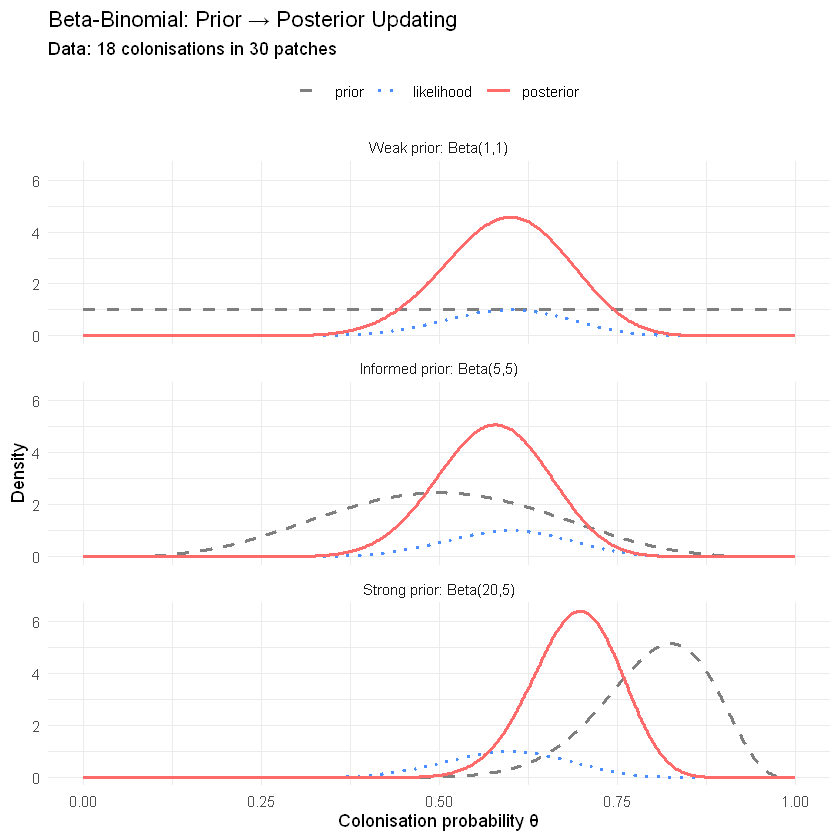

In [2]:
# Estimating colonisation probability θ for a habitat patch
# Prior: Beta(α, β) — encodes prior belief about θ
# Likelihood: Binomial(n, θ) — k successes in n trials
# Posterior: Beta(α + k, β + n - k) — conjugate update

# ── Observed data ─────────────────────────────────────────────────────────────
n_trials  <- 30
k_success <- 18   # 18 out of 30 patches colonised

# ── Prior specifications ──────────────────────────────────────────────────────
priors <- list(
  weak    = c(a=1,   b=1),    # Uniform(0,1) — no prior information
  informed = c(a=5,  b=5),    # Prior mean 0.5 with moderate confidence
  strong  = c(a=20,  b=5)     # Prior mean 0.8 — strong belief in high θ
)

theta <- seq(0, 1, length.out=500)

plot_df <- map_dfr(names(priors), function(nm) {
  a <- priors[[nm]]["a"]; b <- priors[[nm]]["b"]
  a_post <- a + k_success
  b_post <- b + n_trials - k_success
  tibble(
    prior_name = nm,
    theta      = theta,
    prior      = dbeta(theta, a, b),
    likelihood = dbinom(k_success, n_trials, theta),
    posterior  = dbeta(theta, a_post, b_post)
  ) %>%
    mutate(
      likelihood = likelihood / max(likelihood),  # scale to density height
      label      = sprintf("%s prior: Beta(%g,%g) → Beta(%g,%g)",
                           nm, a, b, a_post, b_post)
    )
})

plot_df %>%
  pivot_longer(c(prior, likelihood, posterior),
               names_to="distribution", values_to="density") %>%
  mutate(
    prior_name   = factor(prior_name, levels=names(priors)),
    distribution = factor(distribution, levels=c("prior","likelihood","posterior"))
  ) %>%
  ggplot(aes(x=theta, y=density, color=distribution, linetype=distribution)) +
  geom_line(linewidth=0.9) +
  facet_wrap(~prior_name, ncol=1,
             labeller=labeller(prior_name=c(
               weak="Weak prior: Beta(1,1)",
               informed="Informed prior: Beta(5,5)",
               strong="Strong prior: Beta(20,5)"))) +
  scale_color_manual(
    values=c(prior="gray50", likelihood="#4a8fff", posterior="#ff6b6b")
  ) +
  scale_linetype_manual(values=c(prior="dashed", likelihood="dotted", posterior="solid")) +
  labs(title="Beta-Binomial: Prior → Posterior Updating",
       subtitle=sprintf("Data: %d colonisations in %d patches", k_success, n_trials),
       x="Colonisation probability θ", y="Density",
       color=NULL, linetype=NULL) +
  theme_minimal() +
  theme(legend.position="top")

---

## Posterior Summaries

In [3]:
# Using the weakly informative prior
a_prior <- 1; b_prior <- 1
a_post  <- a_prior + k_success
b_post  <- b_prior + n_trials - k_success

# ── Point estimates ───────────────────────────────────────────────────────────
post_mean   <- a_post / (a_post + b_post)
post_mode   <- (a_post - 1) / (a_post + b_post - 2)   # MAP
post_median <- qbeta(0.5, a_post, b_post)

cat(sprintf("Posterior mean:   %.4f\n", post_mean))
cat(sprintf("Posterior mode:   %.4f  (MAP estimate)\n", post_mode))
cat(sprintf("Posterior median: %.4f\n", post_median))
cat(sprintf("MLE (k/n):        %.4f  (frequentist comparison)\n", k_success/n_trials))

# ── 95% Credible Interval ─────────────────────────────────────────────────────
# Equal-tailed interval (ETI)
eti <- qbeta(c(0.025, 0.975), a_post, b_post)
cat(sprintf("\n95%% ETI: [%.4f, %.4f]\n", eti[1], eti[2]))
# Interpretation: 95% probability that θ ∈ [eti[1], eti[2]] given the data

# ── Highest Density Interval (HDI) ───────────────────────────────────────────
# HDI: the shortest interval containing 95% of posterior probability
# For unimodal symmetric posteriors, ETI ≈ HDI
# For skewed posteriors, HDI is more appropriate
samples <- rbeta(100000, a_post, b_post)
hdi_bounds <- quantile(sort(samples), c(0.025, 0.975))  # approximate for symmetric case
cat(sprintf("95%% HDI (approx): [%.4f, %.4f]\n", hdi_bounds[1], hdi_bounds[2]))

# ── Posterior probability of specific hypotheses ─────────────────────────────
p_above_half  <- pbeta(0.5, a_post, b_post, lower.tail=FALSE)
p_above_0.65  <- pbeta(0.65, a_post, b_post, lower.tail=FALSE)
cat(sprintf("\nP(θ > 0.5  | data) = %.4f\n", p_above_half))
cat(sprintf("P(θ > 0.65 | data) = %.4f\n", p_above_0.65))
# These direct probability statements are not available in frequentist inference

Posterior mean:   0.5938
Posterior mode:   0.6000  (MAP estimate)
Posterior median: 0.5957
MLE (k/n):        0.6000  (frequentist comparison)

95% ETI: [0.4219, 0.7545]
95% HDI (approx): [0.4221, 0.7548]

P(θ > 0.5  | data) = 0.8595
P(θ > 0.65 | data) = 0.2637


---

## MCMC Concepts: A Simple Metropolis Sampler

For illustration only — in practice use `brms`, `NIMBLE`, or `Stan` which implement much more efficient samplers.

Acceptance rate: 82.00%  (target: 23-44% for univariate)


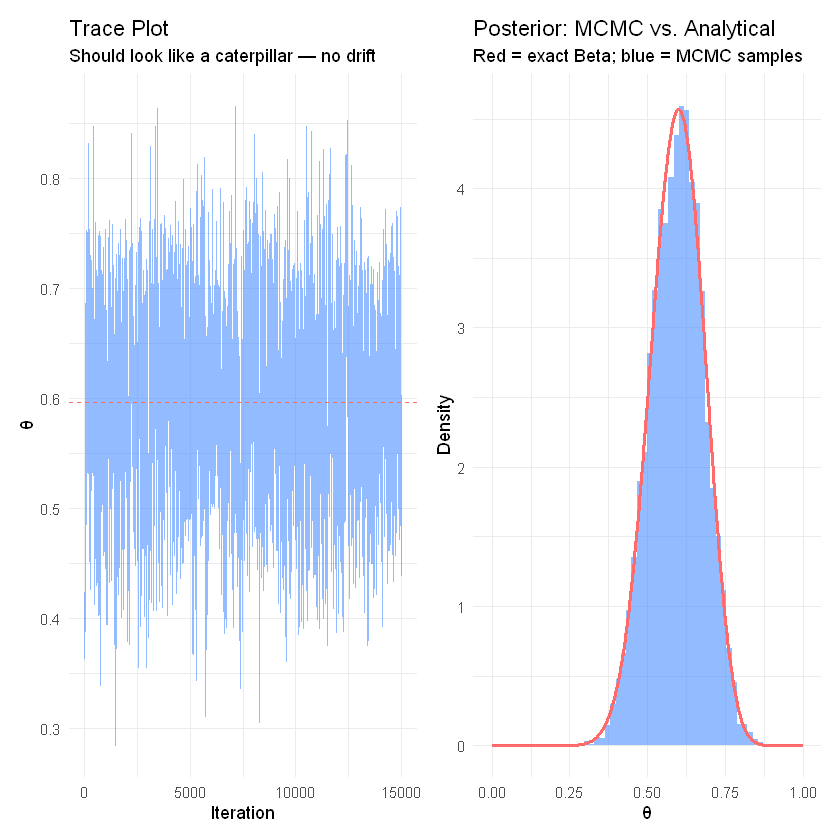

In [4]:
# ── Metropolis-Hastings sampler for Beta-Binomial ─────────────────────────────
# log posterior (up to normalising constant) = log prior + log likelihood
log_posterior <- function(theta, k, n, a, b) {
  if (theta <= 0 | theta >= 1) return(-Inf)
  dbeta(theta, a, b, log=TRUE) + dbinom(k, n, theta, log=TRUE)
}

mh_sampler <- function(n_iter=10000, proposal_sd=0.05,
                        k=k_success, n=n_trials, a=1, b=1) {
  samples <- numeric(n_iter)
  current <- 0.5   # starting value
  accepted <- 0

  for (i in seq_len(n_iter)) {
    proposal <- rnorm(1, current, proposal_sd)
    log_ratio <- log_posterior(proposal, k, n, a, b) -
                 log_posterior(current,  k, n, a, b)
    if (log(runif(1)) < log_ratio) {
      current  <- proposal
      accepted <- accepted + 1
    }
    samples[i] <- current
  }
  list(samples=samples, acceptance_rate=accepted/n_iter)
}

mcmc_result <- mh_sampler(n_iter=20000)
cat(sprintf("Acceptance rate: %.2f%%  (target: 23-44%% for univariate)\n",
            mcmc_result$acceptance_rate * 100))

# Discard burn-in
post_samples <- tail(mcmc_result$samples, 15000)

# ── Trace plot + posterior histogram ─────────────────────────────────────────
p_trace <- ggplot(tibble(iter=seq_along(post_samples), theta=post_samples),
                  aes(x=iter, y=theta)) +
  geom_line(color="#4a8fff", linewidth=0.3, alpha=0.6) +
  geom_hline(yintercept=mean(post_samples), color="#ff6b6b", linetype="dashed") +
  labs(title="Trace Plot", subtitle="Should look like a caterpillar — no drift",
       x="Iteration", y="θ") + theme_minimal()

true_post <- tibble(theta=seq(0,1,0.001),
                    density=dbeta(theta, a_post, b_post))
p_hist <- ggplot(tibble(theta=post_samples), aes(x=theta)) +
  geom_histogram(aes(y=after_stat(density)), bins=60,
                 fill="#4a8fff", alpha=0.6, color=NA) +
  geom_line(data=true_post, aes(x=theta, y=density),
            color="#ff6b6b", linewidth=1) +
  labs(title="Posterior: MCMC vs. Analytical",
       subtitle="Red = exact Beta; blue = MCMC samples",
       x="θ", y="Density") + theme_minimal()

(p_trace | p_hist)

---

## Key Concepts Reference

| Concept | Definition | Notes |
|---|---|---|
| **Prior** | $p(\theta)$ — beliefs before data | Must be specified; see `prior_sensitivity.ipynb` |
| **Likelihood** | $p(y|\theta)$ — data probability under parameter | Identical to frequentist likelihood |
| **Posterior** | $p(\theta|y) \propto p(y|\theta)p(\theta)$ | Full probability distribution over parameters |
| **MAP** | Mode of posterior | Equivalent to penalised MLE |
| **Credible interval** | Interval containing $X$% of posterior probability | Direct probability statement; not a CI |
| **HDI** | Highest density interval — shortest credible interval | Preferred for skewed posteriors |
| **MCMC** | Samples from posterior when no analytical form exists | Check diagnostics — see `mcmc_diagnostics.ipynb` |
| **Burn-in** | Initial samples discarded before chain converges | Discard first 10-50% of iterations |
| **Thinning** | Keeping every $k$th sample | Rarely needed; wastes information |
| **Chains** | Independent MCMC runs | Run ≥4 chains; compare for convergence |

---

## Common Pitfalls

**1. Treating a 95% credible interval like a 95% confidence interval**  
They are fundamentally different. A frequentist 95% CI is a procedure that, over repeated experiments, captures the true parameter 95% of the time — it says nothing about the probability that this particular interval contains the true value. A Bayesian 95% credible interval directly states that the probability the parameter lies in the interval is 0.95, given the data and prior.

**2. Treating the prior as a nuisance**  
The prior is a feature, not a bug. It encodes domain knowledge and regularises estimates in small samples. Choosing a prior carelessly (e.g., flat priors over implausible parameter ranges) is itself an implicit prior choice. Always check prior sensitivity — see `prior_sensitivity.ipynb`.

**3. Not checking MCMC convergence before interpreting results**  
Posterior summaries from a non-converged chain are meaningless. Always check R-hat < 1.01 and ESS > 400 per parameter before reporting results — see `mcmc_diagnostics.ipynb`.

**4. Confusing the MAP estimate with the posterior mean**  
For symmetric posteriors they are similar. For skewed posteriors (common with variance parameters, probabilities near 0 or 1) they can differ substantially. Report the full posterior summary, not just a point estimate.

**5. Stopping model building after getting a converged fit**  
Convergence confirms the sampler worked, not that the model is appropriate. Always run posterior predictive checks to verify the model generates data consistent with observations — see `bayesian_workflow.ipynb`.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*